# 028 自动微分机制与边界

## 目标
验证广播VJP和共享节点，再明确不可微约定、屏障、高阶图和累计语义的边界。先修027、014。本实验只有原创合成诊断，不训练模型、不评价现实表现。

## 设置
在本单元目录重启内核后顺序运行。首格核对固定输入和五份输出，在打印、显示或写入前拒绝不匹配。

In [1]:
from pathlib import Path
import sys, json, csv, math
import numpy as np
import experiment as e
from engine import Tensor, vjp, sum_to_shape
e.require_teaching_inputs()
print("Python", sys.version.split()[0], "NumPy", np.__version__)
print("Fixed config and all five outputs verified.")

Python 3.12.14 NumPy 2.3.5
Fixed config and all five outputs verified.


## 步骤
### 1 一个完整雅可比
F=(x1*x2, x1+x2²)，x=(2,−1)。列梯度约定下VJP为J.T@seed。常数掩码组成向量输出，不新增拼接API。

In [2]:
x1, x2 = Tensor(2.), Tensor(-1.)
out=x1*x2*np.array([1.,0.])+(x1+x2*x2)*np.array([0.,1.])
g=vjp(out,[3.,-1.])
J=np.array([[-1.,2.],[1.,-2.]])
print("output", out.value, "VJP", float(g[x1]), float(g[x2]))
np.testing.assert_array_equal(J.T@np.array([3.,-1.]),[-4.,8.])
assert float(g[x1]) == -4 and float(g[x2]) == 8

output [-2.  3.] VJP -4.0 8.0


### 2 种子与方向不是同一个对象
JVP对应输入方向t，VJP对应输出权重v。内积检查是额外证据，不能替代独立验证J。

In [3]:
direction=np.array([.5,2.]); seed=np.array([3.,-1.])
print("JVP", J@direction)
print("two inner products", seed@(J@direction), (J.T@seed)@direction)
assert seed@(J@direction) == (J.T@seed)@direction == 14.
print("all-ones seed gradients:", float(vjp(out,[1.,1.])[x1]), float(vjp(out,[1.,1.])[x2]))

JVP [ 3.5 -3.5]
two inner products 14.0 14.0
all-ones seed gradients: 0.0 0.0


### 3 广播就是多次使用同一坐标
手算C的行和与列和，保持原输入shape。

u gradient [[ 6.]
 [15.]] shape (2, 1)
v gradient [[5. 7. 9.]] shape (1, 3)


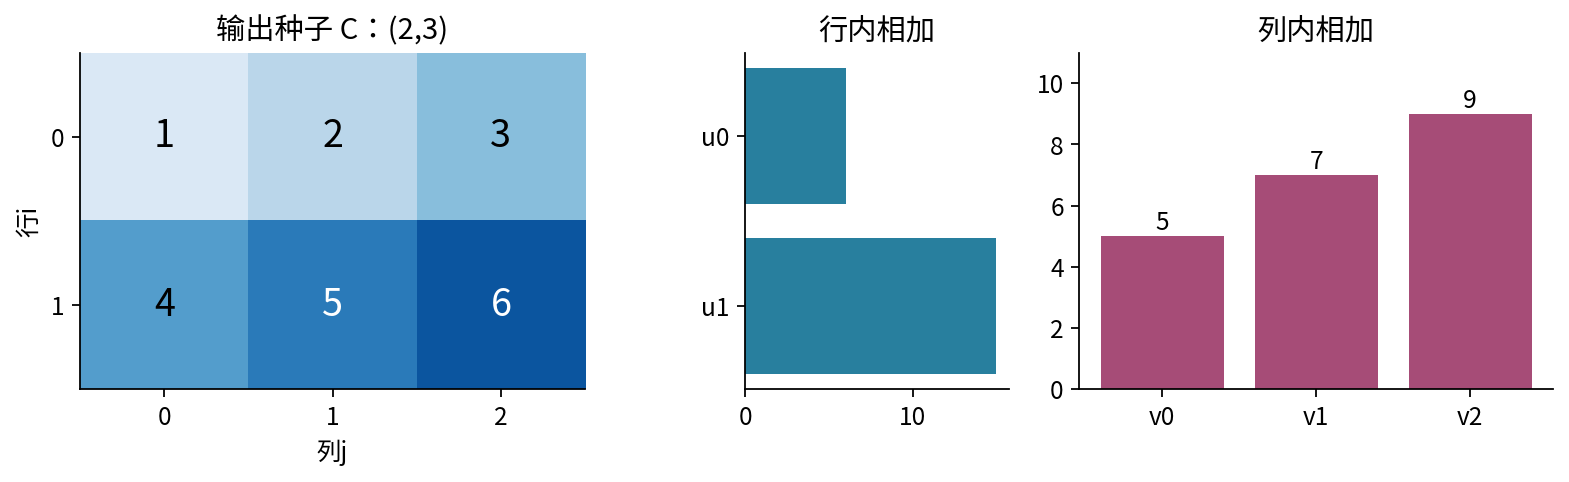

In [4]:
u=Tensor([[1.],[2.]]); vv=Tensor([[.5,-1.,1.5]])
C=np.array([[1.,2.,3.],[4.,5.,6.]])
bg=vjp(u+vv,C)
print("u gradient", bg[u], "shape", bg[u].shape)
print("v gradient", bg[vv], "shape", bg[vv].shape)
np.testing.assert_array_equal(bg[u],[[6.],[15.]])
np.testing.assert_array_equal(bg[vv],[[5.,7.,9.]])
from IPython.display import display, Image
display(Image(filename="figures/03_broadcast_adjoint.png",width=950))

### 4 多轴归约与sum的反向
A(2,1,3)和B(1,4,1)广播成(2,4,3)；返回shape必须准确。

In [5]:
A=Tensor(np.ones((2,1,3)));B=Tensor(np.ones((1,4,1)))
gb=vjp(A+B,np.ones((2,4,3)))
print("unbroadcast shapes",gb[A].shape,gb[B].shape)
np.testing.assert_array_equal(gb[A],np.full((2,1,3),4.))
np.testing.assert_array_equal(gb[B],np.full((1,4,1),6.))
X=Tensor(np.arange(24.).reshape(2,3,4))
red=X.sum(axis=(0,2))
gr=vjp(red,[1.,2.,3.])[X]
print("reduced",red.shape,"pulled back",gr.shape,"one input slice",gr[0,:,0])

unbroadcast shapes (2, 1, 3) (1, 4, 1)
reduced (3,) pulled back (2, 3, 4) one input slice [1. 2. 3.]


### 5 主图前向与均值目标
L=sum(tanh(A)²+tanh(A))/6只是微分检查目标，可以为负。它不是现实预测误差。

In [6]:
cfg=e.read_config("data/config.json")
nodes=e.build(cfg["X"],cfg["w"],cfg["b"])
mean_g=vjp(nodes["L"])
for name,node in nodes.items():
    print(name,"shape",node.shape,"value",node.value)
print("gw",mean_g[nodes["w"]],"gb",mean_g[nodes["b"]])
assert abs(float(mean_g[nodes["X"]][0,1])+1/24)<1e-16

X shape (2, 3) value [[-1.   0.5  1. ]
 [ 0.   1.  -0.5]]
w shape (3,) value [ 0.5  -0.25  0.75]
b shape () value 0.125
a shape (2, 3) value [[-0.375  0.     0.875]
 [ 0.125 -0.125 -0.25 ]]
h shape (2, 3) value [[-0.3583574   0.          0.7039056 ]
 [ 0.124353   -0.124353   -0.24491866]]
z shape (2, 3) value [[-0.22993737  0.          1.1993887 ]
 [ 0.13981667 -0.10888933 -0.18493351]]
L shape () value 0.13590752611351406
gw [-0.04115095  0.20661271  0.1625002 ] gb 0.8183867184149809


### 6 相同前向，不同输出加权
给Z非均匀种子，目标不再是均值；用独立普通Python逐坐标公式核对。

In [7]:
weighted=vjp(nodes["z"],cfg["seed"])
reference=e.scalar_reference(cfg["X"],cfg["w"],cfg["b"],cfg["seed"])
for key,ref in zip(["X","w","b"],reference):
    np.testing.assert_allclose(weighted[nodes[key]],ref,atol=1e-14,rtol=0)
print("weighted gw",weighted[nodes["w"]],"weighted gb",weighted[nodes["b"]])

weighted gw [-0.24690571  0.10951435  0.84717097] weighted gb -0.20840059658011773


### 7 差分扫描保留全部坐标
五份文件中的finite_difference.csv包含9步长×10坐标，而不是单个最佳步长。

max absolute error at1e-5: 9.154871305483425e-12


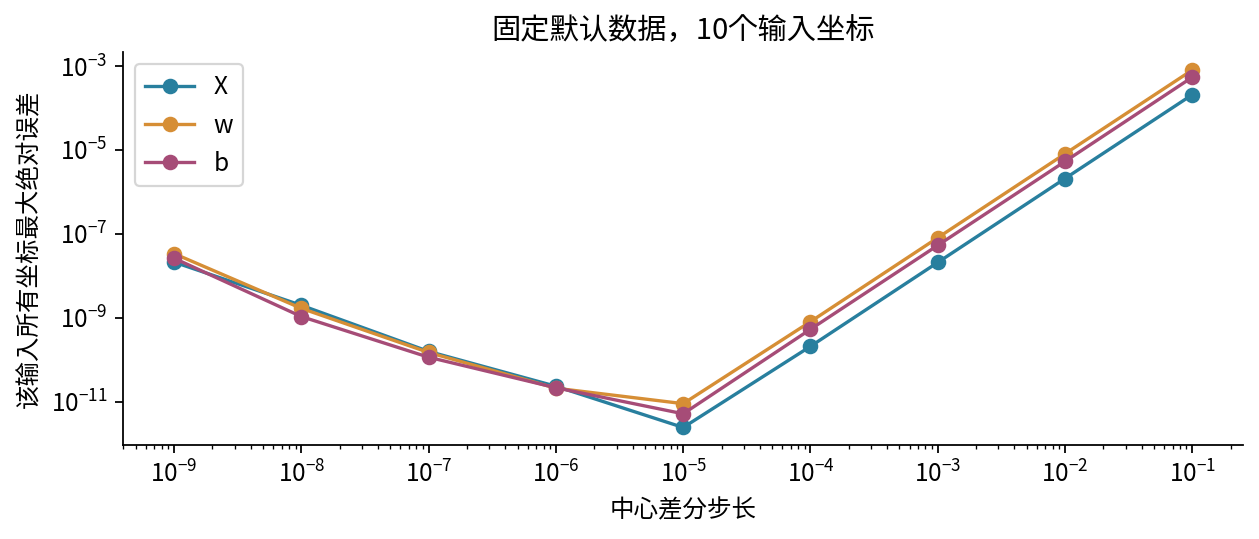

In [8]:
e.require_teaching_inputs()
fd=list(csv.DictReader(Path("outputs/finite_difference.csv").open()))
assert len(fd)==90
selected=[float(r["absolute_error"]) for r in fd if float(r["epsilon"])==1e-5]
print("max absolute error at1e-5:",max(selected))
assert max(selected)<1e-8
display(Image(filename="figures/07_finite_difference.png",width=850))

### 8 非光滑局部规则不保证整体导数
ReLU(x)−ReLU(−x)作为数值函数恒等于x，却在x=0处按本引擎局部约定返回0。

In [9]:
for value in [-1.,0.,1.]:
    x=Tensor(value);r=x.relu()-(-x).relu()
    print("input",value,"forward",float(r.value),"returned gradient",float(vjp(r)[x]))
x=Tensor(0.)
assert float(vjp(x.relu()-(-x).relu())[x])==0.
print("Ordinary derivative of the simplified identity function is1.")

input -1.0 forward -1.0 returned gradient 1.0
input 0.0 forward 0.0 returned gradient 0.0
input 1.0 forward 1.0 returned gradient 1.0
Ordinary derivative of the simplified identity function is1.


### 9 梯度屏障故意改变反向规则
两个前向数值都是8。屏障版本返回4，不能冒充普通x³在2处的导数12。

In [10]:
x=Tensor(2.);normal=x*x*x;blocked=(x*x).detach()*x
print("normal",float(normal.value),float(vjp(normal)[x]))
print("blocked",float(blocked.value),float(vjp(blocked)[x]))
assert float(normal.value)==float(blocked.value)==8
assert float(vjp(normal)[x])==12 and float(vjp(blocked)[x])==4

normal 8.0 12.0
blocked 8.0 4.0


### 10 数值梯度不是导数计算图
手动重新写出导数表达式，再做一阶VJP；这一人工步骤不等于自动高阶微分。

f 0.28125 first 1.5 rebuilt second 5.5
Expected rejection: numeric gradient is not a Tensor graph.


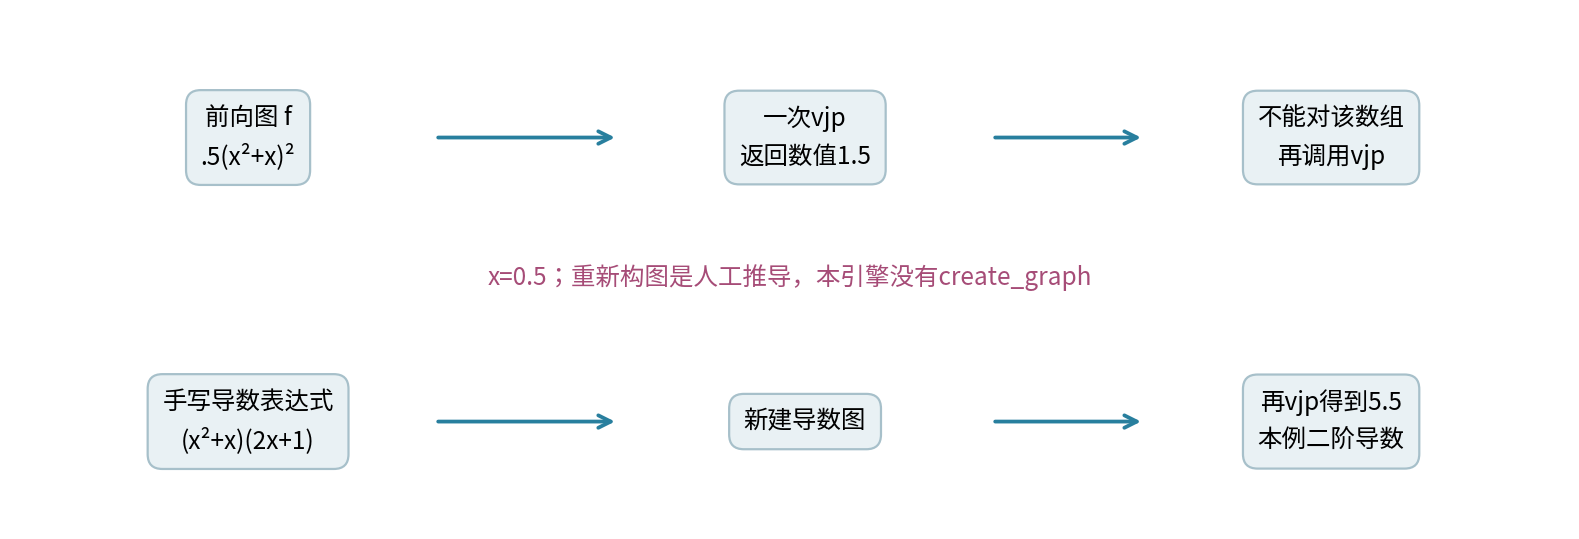

In [11]:
x=Tensor(.5);r=x*x+x;f=.5*r*r
df=(x*x+x)*(2*x+1)
print("f",float(f.value),"first",float(vjp(f)[x]),"rebuilt second",float(vjp(df)[x]))
assert float(vjp(f)[x])==1.5 and float(vjp(df)[x])==5.5
try:
    vjp(vjp(f)[x])
except ValueError:
    print("Expected rejection: numeric gradient is not a Tensor graph.")
else:
    raise AssertionError("Numeric gradient incorrectly accepted as a derivative graph")
e.require_teaching_inputs()
display(Image(filename="figures/10_higher_order.png",width=950))

### 11 快照、复制与独立调用
外部数组变化不会更新旧图。新一轮参数要重新前向；两个VJP字典不自动累计。

In [12]:
source=np.array([2.,3.]);x=Tensor(source);r=x*x;source[:]=0
shown=x.value;shown.setflags(write=True);shown[:]=99
np.testing.assert_array_equal(x.value,[2.,3.])
g1=vjp(r,[1.,1.]);g2=vjp(r,[1.,1.]);g1[x][0]=999
np.testing.assert_array_equal(g2[x],[4.,6.])
print("Snapshot unchanged; gradient maps independent.")

Snapshot unchanged; gradient maps independent.


## 检查
### 12 运行独立测试
分数逐索引、差分完整J、高精度tanh、手算、形状、数值范围、别名及失败输出隔离一起验证。

In [13]:
import unittest,io
import test_experiment
stream=io.StringIO();result=unittest.TextTestRunner(stream=stream,verbosity=0).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
assert result.wasSuccessful(),stream.getvalue()
print("Test groups passed:",result.testsRun)

Test groups passed: 13


### 13 重新生成五份结果
输入、计算和序列化完成后才开始写出，仍不声称操作系统多文件写入原子性。

In [14]:
e.require_teaching_inputs()
summary=e.run(output="notebook_outputs")
for name in e.OUTPUT_NAMES:
    assert (Path("notebook_outputs")/name).read_bytes()==(Path("outputs")/name).read_bytes()
print("All five outputs match byte for byte.")
print("Main objective:",summary["mean_objective"])

All five outputs match byte for byte.
Main objective: 0.13590752611351406


### 14 错误种子必须明确失败
禁止自动广播种子，不替使用者猜输出的归约含义。

In [15]:
for seed in [None,1.,[[1.,1.]]]:
    y=Tensor([1.,2.])
    try:
        vjp(y,seed)
    except ValueError:
        print("Expected seed-shape rejection:",seed)
    else:
        raise AssertionError("Invalid seed accepted")

Expected seed-shape rejection: None
Expected seed-shape rejection: 1.0
Expected seed-shape rejection: [[1.0, 1.0]]


## 下一步
提交lab.pdf中的完整雅可比、广播来源索引和三类边界解释。梯度检查不能验证建模目标、数据拆分、优化或泛化。029会实际使用PyTorch，继续检查dtype、leaf、detach、no_grad和累积语义。

本次为新进程真实InProcessKernel顺序执行；全新Anaconda、浏览器Jupyter、外部socket、GPU和跨平台未测试。JAX/PyTorch只查官方文档，没有在本单元执行。